In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

LOAD DATASET

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')

X_train shape: (60000, 28, 28)
y_train shape: (60000,)


In [ ]:
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

X_test shape: (10000, 28, 28)
y_test shape: (10000,)


EDA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

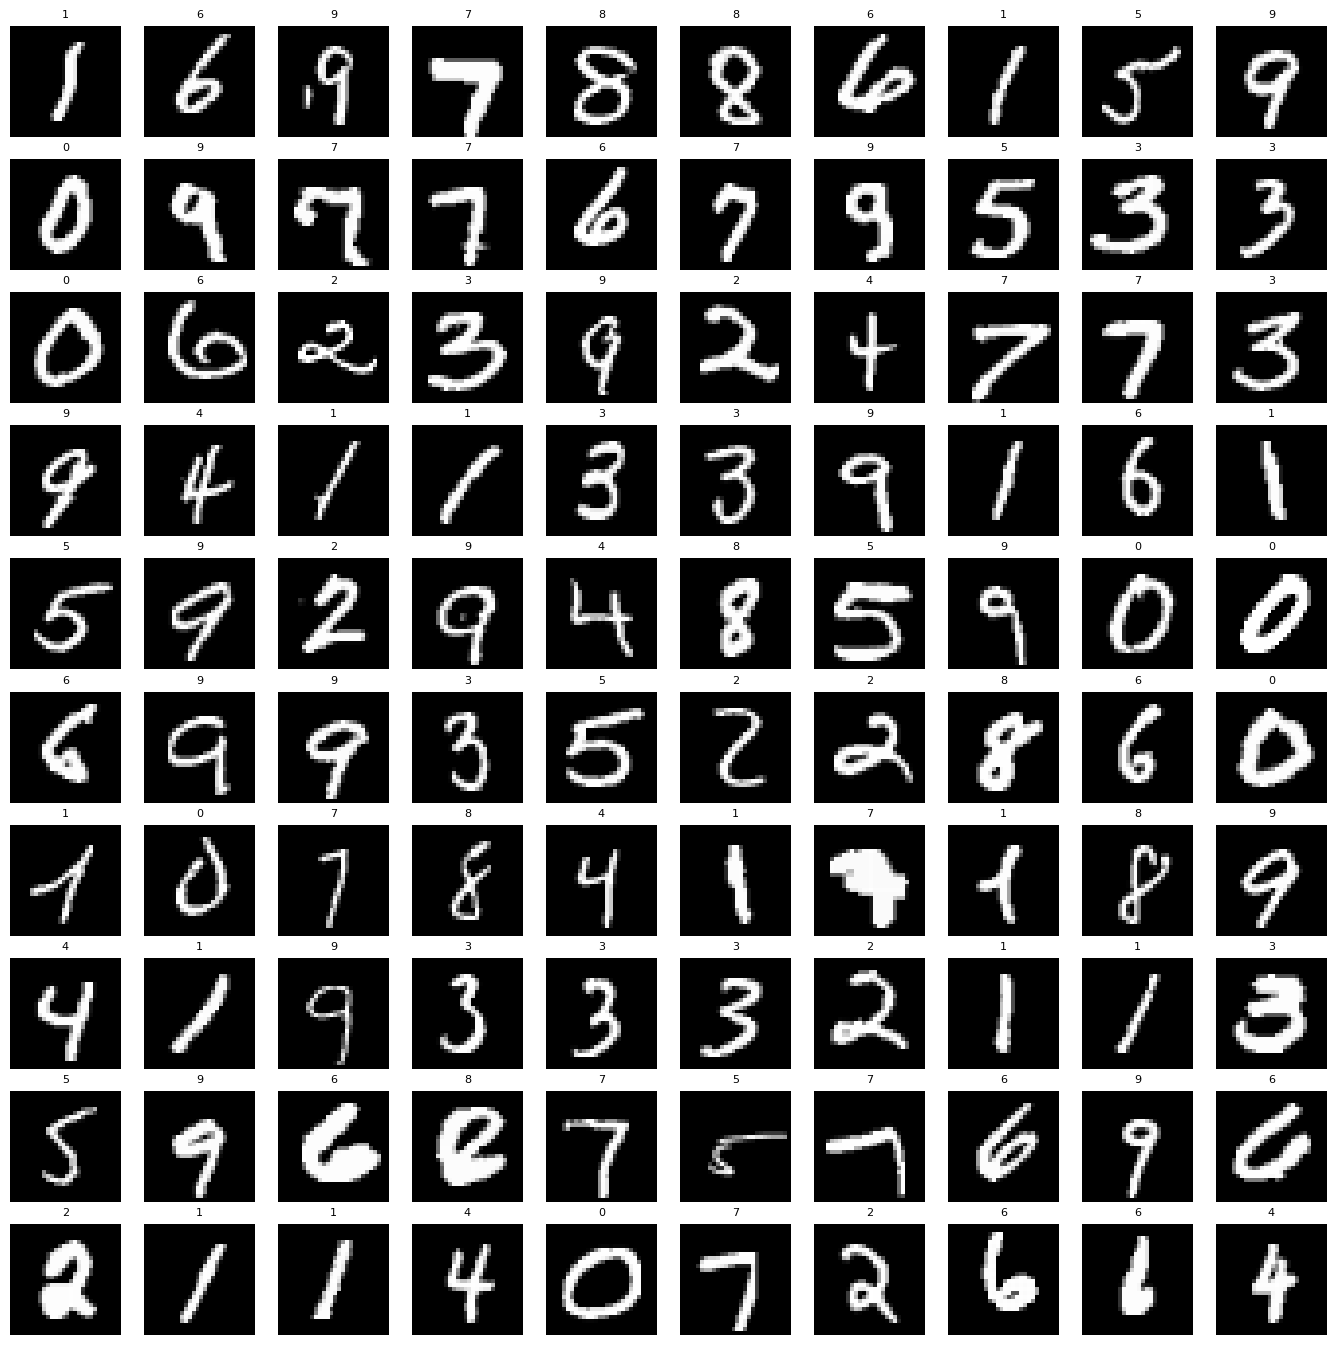

In [ ]:
labels = [0,1,2,3,4,5,6,7,8,9]
W_grid = 10
L_grid = 10
fig, axes = plt.subplots(L_grid, W_grid, figsize = (17, 17))
axes = axes.ravel()
n_train = len(X_train)
for i in np.arange(0, W_grid * L_grid):
  index = np.random.randint(0, n_train)
  axes[i].imshow(X_train[index], cmap="gray")
  label_index = int(y_train[index])
  axes[i].set_title(labels[label_index],fontsize=8)
  axes[i].axis('off')
plt.subplots_adjust(hspace = 0.2)

PRE-PROCESSING

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
X_train = np.expand_dims(X_train, axis=-1)
X_test  = np.expand_dims(X_test, axis=-1)

In [ ]:
from tensorflow.keras.utils import to_categorical

y_cat_train = to_categorical(y_train, 10)
y_cat_test = to_categorical(y_test, 10)

In [ ]:
print(f"Train:\n{y_cat_train} \n\n Test:\n{y_cat_test}")

Train:
[[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]] 

 Test:
[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization)
INPUT_SHAPE = (28, 28, 1)
KERNEL_SIZE = (3, 3)
model = Sequential()
# Convolutional Layer
model.add(Conv2D(filters = 32, kernel_size = KERNEL_SIZE, input_shape = INPUT_SHAPE, activation = 'relu', padding = 'same'))
model.add(BatchNormalization())
model.add(Conv2D(filters = 32, kernel_size = KERNEL_SIZE, activation = 'relu', padding = 'same'))
model.add(BatchNormalization())
# 1Pooling Layer
model.add(MaxPool2D(pool_size = (2, 2)))
# 1Dropout Layer
model.add(Dropout(0.25))
model.add(Conv2D(filters = 64, kernel_size = KERNEL_SIZE, activation = 'relu', padding = 'same'))
model.add(BatchNormalization())
model.add(Conv2D(filters = 64, kernel_size = KERNEL_SIZE, activation = 'relu', padding = 'same'))
model.add(BatchNormalization())
# 2Pooling Layer
model.add(MaxPool2D(pool_size = (2, 2)))
# 2Dropout Layer
model.add(Dropout(0.25))
model.add(Conv2D(filters = 128, kernel_size = KERNEL_SIZE, activation = 'relu', padding = 'same'))
model.add(BatchNormalization())
model.add(Conv2D(filters = 128, kernel_size = KERNEL_SIZE, activation = 'relu', padding = 'same'))
model.add(BatchNormalization())
# 3Pooling Layer
model.add(MaxPool2D(pool_size = (2, 2)))
# 3Dropout Layer
model.add(Dropout(0.25))
model.add(Conv2D(filters = 128, kernel_size = KERNEL_SIZE, activation = 'relu', padding = 'same'))
model.add(BatchNormalization())
model.add(Conv2D(filters = 128, kernel_size = KERNEL_SIZE, activation = 'relu', padding = 'same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation = 'relu'))
model.add(Dense(64, activation = 'relu'))
# model.add(Dropout(0.5))
model.add(Dense(10, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix
METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]
model.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=METRICS)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 3, 3, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 3, 3, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 609,834 (2.33 MB)

 Trainable params: 608,426 (2.32 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience = 2)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
batch_size = 32
data_generator = ImageDataGenerator(width_shift_range = 0.1, height_shift_range = 0.1, horizontal_flip = False)
train_generator = data_generator.flow(X_train, y_cat_train, batch_size)
steps_per_epoch = X_train.shape[0] // batch_size
r = model.fit(train_generator, epochs = 50, steps_per_epoch = steps_per_epoch, validation_data=(X_test, y_cat_test), callbacks=[early_stop], batch_size=batch_size)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.9263 - loss: 0.2304 - precision: 0.9574 - recall: 0.9102 - val_accuracy: 0.9794 - val_loss: 0.0666 - val_precision: 0.9821 - val_recall: 0.9777
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9787 - loss: 0.0750 - precision: 0.9815 - recall: 0.9757 - val_accuracy: 0.9886 - val_loss: 0.0440 - val_precision: 0.9898 - val_recall: 0.9881
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9815 - loss: 0.0638 - precision: 0.9838 - recall: 0.9795 - val_accuracy: 0.9900 - val_loss: 0.0311 - val_precision: 0.9917 - val_recall: 0.9890
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9850 - loss: 0.0540 - precision: 0.9866 - recall: 0.9834 - val_accuracy: 0.9922 - val_loss: 0.0280 - val_precision: 0.9934 - val_recall: 0.9917
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9867 - loss: 0.0473 - precision: 0.9882 - recall: 0.9853 - val_accuracy: 0

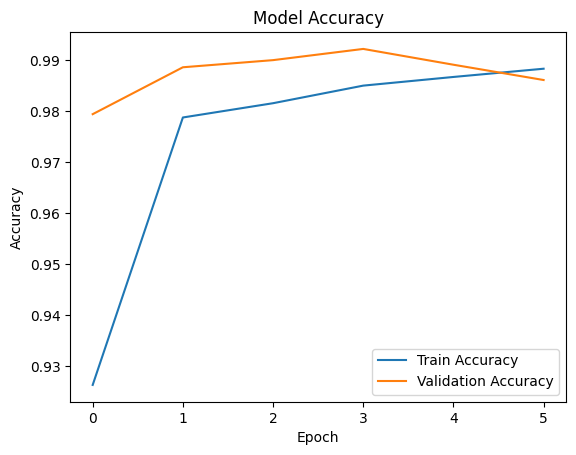

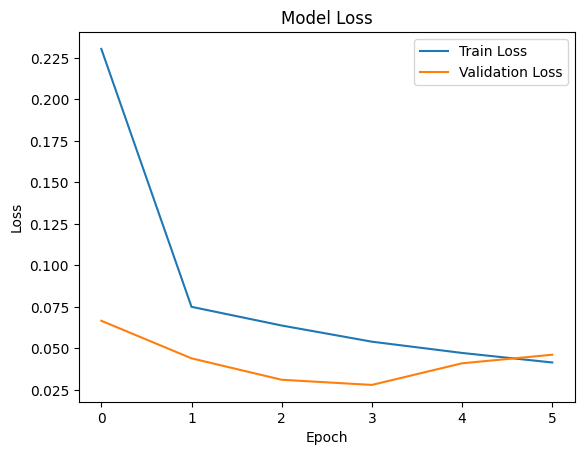

In [ ]:
plt.figure()
plt.plot(r.history['accuracy'])
plt.plot(r.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()

plt.figure()
plt.plot(r.history['loss'])
plt.plot(r.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


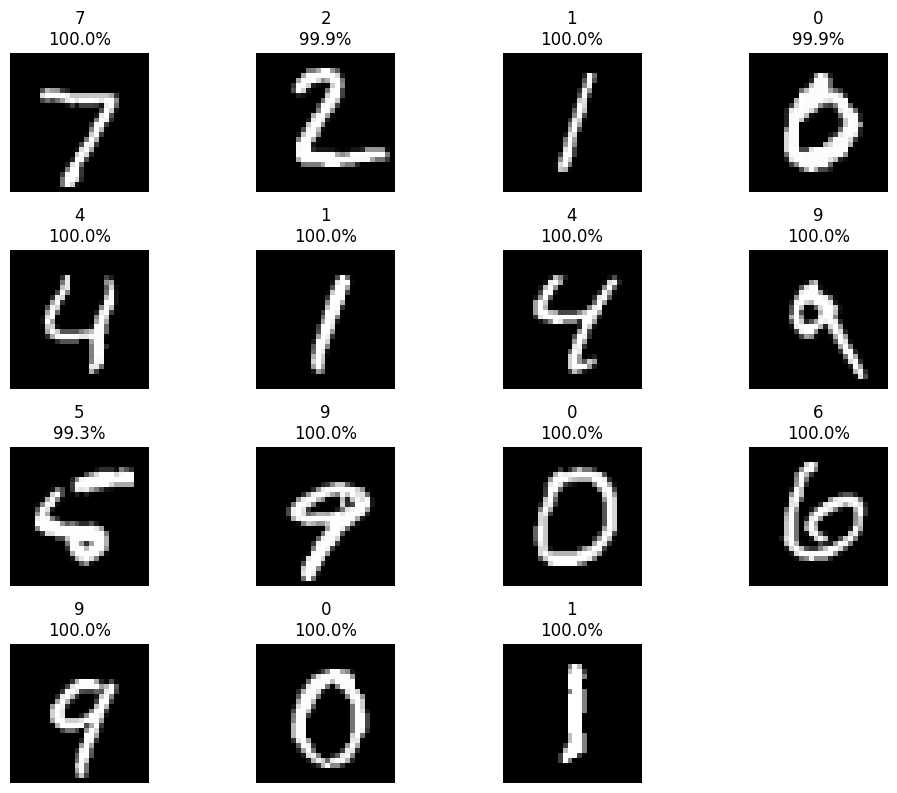

In [ ]:
predictions = model.predict(X_test)

num_images = 15
plt.figure(figsize=(10,10))

for i in range(num_images):
    plt.subplot(5, 4, i+1)

    img = X_test[i]
    pred = predictions[i]

    predicted_class = np.argmax(pred)
    confidence = np.max(pred)

    plt.imshow(img, cmap='gray')
    plt.axis('off')

    plt.title(f"{labels[predicted_class]}\n{confidence*100:.1f}%")

plt.tight_layout()
plt.show()

Saving test_image6.jpeg to test_image6 (1).jpeg


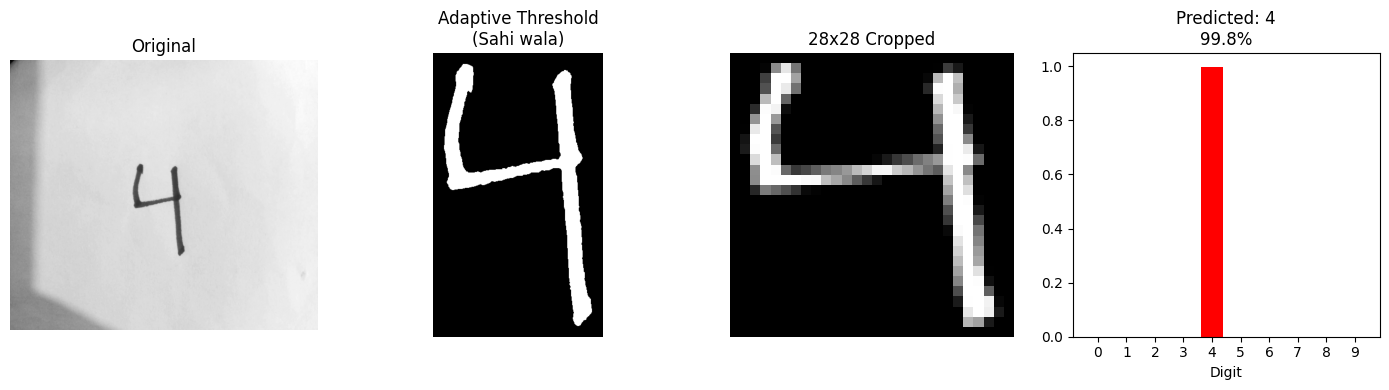


✅ Predicted: 4  |  Confidence: 99.8%


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

def predict_digit(img_path):

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    img_thresh = cv2.adaptiveThreshold(
        img,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,  # local area ka gaussian average
        cv2.THRESH_BINARY_INV,           # digit white, background black
        blockSize=101,                     # kitne bade area mein calculate kare
        C=10                              # threshold se kitna subtract kare
    )

    kernel = np.ones((3, 3), np.uint8)
    img_thresh = cv2.morphologyEx(img_thresh, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(img_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)

        pad = 20
        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(img_thresh.shape[1], x + w + pad)
        y2 = min(img_thresh.shape[0], y + h + pad)

        img_thresh = img_thresh[y1:y2, x1:x2]

    img_final = cv2.resize(img_thresh, (28, 28), interpolation=cv2.INTER_AREA)
    arr_final = img_final / 255.0

    fig, axes = plt.subplots(1, 4, figsize=(14, 4))

    axes[0].imshow(img, cmap='gray')
    axes[0].set_title("Original")
    axes[0].axis('off')

    axes[1].imshow(img_thresh, cmap='gray')
    axes[1].set_title("Adaptive Threshold\n(Sahi wala)")
    axes[1].axis('off')

    axes[2].imshow(arr_final, cmap='gray')
    axes[2].set_title("28x28 Cropped")
    axes[2].axis('off')

    model_input = arr_final.reshape(1, 28, 28, 1)
    prediction = model.predict(model_input, verbose=0)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    axes[3].bar(range(10), prediction[0], color=['red' if i == predicted_class else 'steelblue' for i in range(10)])
    axes[3].set_xticks(range(10))
    axes[3].set_title(f"Predicted: {predicted_class}\n{confidence*100:.1f}%")
    axes[3].set_xlabel("Digit")

    plt.tight_layout()
    plt.show()

    print(f"\n✅ Predicted: {predicted_class}  |  Confidence: {confidence*100:.1f}%")

from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
predict_digit(img_path)